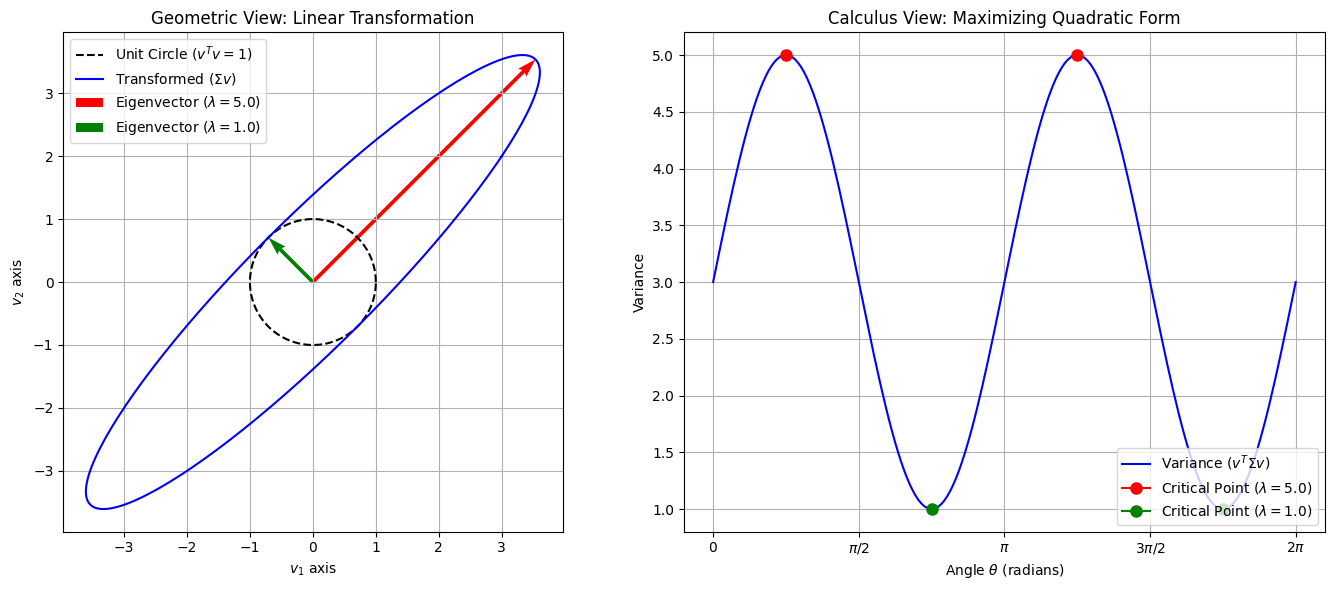

In [1]:
'''
~
이 코드는 다차원 확률 변수의 분산을 최대화하는 주성분 분석(PCA)의 기하학적 의미를 2차원 평면에서 시각화합니다.
이전 대화에서 설계한 대로, 제약 조건인 단위 구면(원)과 공분산 행렬에 의한 선형 변환(타원체), 
그리고 이차 형식(목적 함수)의 스칼라 값 변화를 나란히 비교하여 극대점과 고유벡터의 일치를 증명합니다.
달라진 점: 추상적인 수식 전개에서 벗어나, 구체적인 2x2 대칭 행렬을 설정하여 실제 좌표값과 그래프로 논리를 검증하도록 구현했습니다.
~
'''
import numpy as np
import matplotlib.pyplot as plt

# 1. 공분산 행렬 설정 (대칭 행렬 및 비대각 성분 포함)
Sigma = np.array([[3, 2], 
                  [2, 3]])

# 2. 고윳값 및 고유벡터 연산
eigenvalues, eigenvectors = np.linalg.eig(Sigma)

# 3. 제약 조건 설정: 각도 theta에 따른 2차원 단위 벡터 V 생성 (크기가 1인 탐색 공간)
theta = np.linspace(0, 2*np.pi, 200)
V = np.array([np.cos(theta), np.sin(theta)]) # 형상: (2, 200)

# 4. 선형 변환 및 이차 형식(분산) 계산
Sigma_V = Sigma @ V                          # 행렬 변환: 타원체 생성
variance = np.sum(V * Sigma_V, axis=0)       # 목적 함수 연산: v^T * Sigma * v

# 5. 시각화 설정
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: 기하학적 관점 (단위원과 선형 변환) ---
# 단위원 (제약 조건) 그리기
ax1.plot(V[0, :], V[1, :], 'k--', label='Unit Circle ($v^T v = 1$)')
# 선형 변환된 타원체 그리기
ax1.plot(Sigma_V[0, :], Sigma_V[1, :], 'b-', label='Transformed ($\Sigma v$)')

# 고유벡터 시각화 (장축과 단축)
colors = ['r', 'g']
for i in range(2):
    lam = eigenvalues[i]
    vec = eigenvectors[:, i]
    # 고윳값 크기만큼 벡터 길이를 늘려서 화살표로 표시
    ax1.quiver(0, 0, vec[0]*lam, vec[1]*lam, angles='xy', scale_units='xy', scale=1, 
               color=colors[i], label=f'Eigenvector ($\\lambda={lam:.1f}$)')

ax1.set_aspect('equal')
ax1.set_title('Geometric View: Linear Transformation')
ax1.set_xlabel('$v_1$ axis')
ax1.set_ylabel('$v_2$ axis')
ax1.grid(True)
ax1.legend(loc='upper left')

# --- Plot 2: 대수학적 관점 (목적 함수의 최적화) ---
# 각도에 따른 분산 변화 그래프
ax2.plot(theta, variance, 'b-', label='Variance ($v^T \Sigma v$)')

# 고유벡터가 위치한 각도 찾기 및 극점 표시
for i in range(2):
    vec = eigenvectors[:, i]
    # 고유벡터의 각도 계산 (아크탄젠트)
    angle = np.arctan2(vec[1], vec[0])
    if angle < 0:
        angle += 2*np.pi
        
    # 해당 각도에서의 분산값(고윳값과 일치)에 점 찍기
    ax2.plot(angle, eigenvalues[i], marker='o', markersize=8, color=colors[i], 
             label=f'Critical Point ($\\lambda={eigenvalues[i]:.1f}$)')
    # 반대 방향(180도) 고유벡터 위치 표시
    angle_opp = (angle + np.pi) % (2*np.pi)
    ax2.plot(angle_opp, eigenvalues[i], marker='o', markersize=8, color=colors[i])

ax2.set_title('Calculus View: Maximizing Quadratic Form')
ax2.set_xlabel('Angle $\\theta$ (radians)')
ax2.set_ylabel('Variance')
ax2.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax2.set_xticklabels(['$0$', '$\\pi/2$', '$\\pi$', '$3\\pi/2$', '$2\\pi$'])
ax2.grid(True)
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

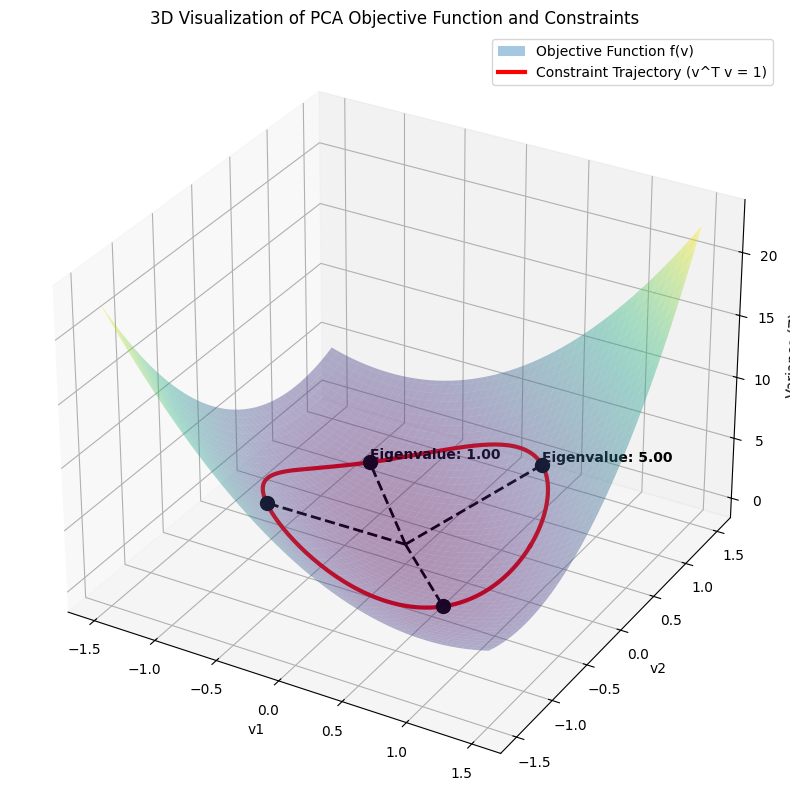

In [3]:
import numpy as np
import matplotlib.pyplot as plt

'''
이 코드는 다차원 확률 변수의 분산을 최대화하는 주성분 분석(PCA)의 목적 함수를 
3차원 공간에서 시각화합니다.
이전 대화에서 논의한 라그랑주 승수법의 제약 조건(단위원)이 
목적 함수(이차 형식 곡면)와 만나는 3차원 궤적을 그리고, 
고유값 분해를 통해 도출된 극대점/극소점이 실제 궤적의 최고점/최저점과 
일치함을 기하학적으로 증명합니다.
'''

# 1. 2x2 양의 정부호 공분산 행렬 정의 (회전된 타원체를 위해 비대각 성분 추가)
Sigma = np.array([[3, 2], 
                  [2, 3]])

# 2. X, Y 그리드 생성 (v1, v2 공간)
v1 = np.linspace(-1.5, 1.5, 100)
v2 = np.linspace(-1.5, 1.5, 100)
V1, V2 = np.meshgrid(v1, v2)

# 3. 목적 함수 f(v1, v2) = v^T * Sigma * v 계산 (3D 곡면의 Z값)
# 행렬 연산을 벡터화하여 그리드 전체에 적용
Z_surface = Sigma[0,0]*V1**2 + (Sigma[0,1] + Sigma[1,0])*V1*V2 + Sigma[1,1]*V2**2

# 4. 제약 조건 생성 (v^T * v = 1 인 단위원 궤적)
theta = np.linspace(0, 2*np.pi, 200)
v1_circle = np.cos(theta)
v2_circle = np.sin(theta)

# 5. 제약 조건 궤적을 목적 함수 곡면 위로 투영 (궤적의 Z값 계산)
Z_trajectory = np.zeros_like(theta)
for i in range(len(theta)):
    v_vec = np.array([v1_circle[i], v2_circle[i]])
    Z_trajectory[i] = v_vec.T @ Sigma @ v_vec

# 6. 수학적 정답 (고유값과 고유벡터) 계산
eigenvalues, eigenvectors = np.linalg.eig(Sigma)

# 3D 시각화 설정
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# 3D 그릇 모양 곡면 그리기 (투명도를 주어 궤적이 잘 보이게 함)
surf = ax.plot_surface(V1, V2, Z_surface, cmap='viridis', alpha=0.4, 
                       edgecolor='none', label='Objective Function f(v)')
surf._facecolors2d = surf._facecolor3d
surf._edgecolors2d = surf._edgecolor3d

# 제약 조건 곡선 (롤러코스터 궤적) 그리기
ax.plot(v1_circle, v2_circle, Z_trajectory, color='red', linewidth=3, 
        label='Constraint Trajectory (v^T v = 1)')

# 고유벡터가 가리키는 점 (극대/극소점) 표기
for i in range(2):
    lam = eigenvalues[i]
    vec = eigenvectors[:, i]
    
    # 양의 방향 고유벡터 점
    ax.scatter(vec[0], vec[1], lam, color='black', s=100, zorder=5)
    ax.plot([0, vec[0]], [0, vec[1]], [0, lam], color='black', linestyle='--', linewidth=2)
    ax.text(vec[0], vec[1], lam + 0.3, f'Eigenvalue: {lam:.2f}', color='black', fontweight='bold')

    # 음의 방향 고유벡터 점 (원점 대칭)
    ax.scatter(-vec[0], -vec[1], lam, color='black', s=100, zorder=5)
    ax.plot([0, -vec[0]], [0, -vec[1]], [0, lam], color='black', linestyle='--', linewidth=2)

# 축 라벨 및 타이틀 설정
ax.set_xlabel('v1')
ax.set_ylabel('v2')
ax.set_zlabel('Variance (Z)')
ax.set_title('3D Visualization of PCA Objective Function and Constraints')
ax.legend()

plt.show()

In [1]:
'''
이 코드는 다차원 확률 변수의 분산을 최대화하는 주성분 분석(PCA)의 목적 함수를 
3차원 공간에서 시각화합니다.
이전 대화(Matplotlib 사용)와 달라진 점:
사용자가 3D 그래프를 마우스로 직접 드래그하여 회전하고 확대/축소할 수 있도록, 
인터랙티브 시각화 라이브러리인 Plotly를 사용하여 코드를 전면 재작성했습니다.
'''
import numpy as np
import plotly.graph_objects as go

# 1. 공분산 행렬 정의
Sigma = np.array([[1, 2], 
                  [2, 2]])

# 2. X, Y 그리드 생성
v1 = np.linspace(-1.5, 1.5, 100)
v2 = np.linspace(-1.5, 1.5, 100)
V1, V2 = np.meshgrid(v1, v2)

# 3. 목적 함수 곡면(Z) 연산
Z_surface = Sigma[0,0]*V1**2 + (Sigma[0,1] + Sigma[1,0])*V1*V2 + Sigma[1,1]*V2**2

# 4. 제약 조건(단위원) 궤적 생성
theta = np.linspace(0, 2*np.pi, 200)
v1_circle = np.cos(theta)
v2_circle = np.sin(theta)
Z_trajectory = np.zeros_like(theta)
for i in range(len(theta)):
    v_vec = np.array([v1_circle[i], v2_circle[i]])
    Z_trajectory[i] = v_vec.T @ Sigma @ v_vec

# 5. 고윳값과 고유벡터 연산
eigenvalues, eigenvectors = np.linalg.eig(Sigma)

# 6. Plotly 객체 생성
fig = go.Figure()

# 목적 함수 곡면 시각화 추가
fig.add_trace(go.Surface(z=Z_surface, x=v1, y=v2, opacity=0.6, colorscale='Viridis', name='목적 함수 f(v)'))

# 제약 조건 궤적 시각화 추가
fig.add_trace(go.Scatter3d(x=v1_circle, y=v2_circle, z=Z_trajectory, 
                           mode='lines', line=dict(color='red', width=6), name='제약 조건 궤적'))

# 고유벡터(극대/극소점) 표기
for i in range(2):
    lam = eigenvalues[i]
    vec = eigenvectors[:, i]
    
    # 양의 방향 고유벡터 선분
    fig.add_trace(go.Scatter3d(x=[0, vec[0]], y=[0, vec[1]], z=[0, lam],
                               mode='lines+markers', marker=dict(size=5, color='black'),
                               line=dict(color='black', width=4, dash='dash'),
                               name=f'고윳값: {lam:.2f}'))
    
    # 음의 방향 고유벡터 선분 (원점 대칭)
    fig.add_trace(go.Scatter3d(x=[0, -vec[0]], y=[0, -vec[1]], z=[0, lam],
                               mode='lines+markers', marker=dict(size=5, color='black'),
                               line=dict(color='black', width=4, dash='dash'),
                               showlegend=False))

# 레이아웃 및 뷰 설정
fig.update_layout(title='PCA 목적 함수와 제약 조건의 3D 인터랙티브 시각화',
                  scene=dict(xaxis_title='v1', yaxis_title='v2', zaxis_title='Variance (Z)'),
                  width=900, height=800)

# 브라우저에 그래프 출력
fig.show()